# SVM(Support Vector Machine)
- SVC(분류),SVR(회귀)
- 딥러닝이 등장하기 전의, 가장 성능 좋은 머신러닝 알고리즘
- 저차원, 고차원 데이터에 모두 잘 작동
  - 샘플이 많을때는 적합하지 않음
- SVM은 데이터를 보고 두 클래스를 가장 잘 나누는 경계를 찾음
  - 경계가 되는 두 백터를 선정하고 중간에 결정경계를 선점
  - 결정 경계를 중심으로 클래스 분류

# 01. 펭귄 종 분류하기
- 미국 팔머연구소에서 수집한 총 344마리의 펭귄정보
- 특징 : 종, 서식지, 부리의 길이, 부리의 두께, 물갈퀴의 길이, 체중, 성별
- 종류 : 아델리펭귄, 젠투 펭귄, 턴끈 펭귄

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/penguins.csv')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [3]:
data.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [4]:
data.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [5]:
data['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [6]:
data['island'].value_counts()

,count
island,
Biscoe,168
Dream,124
Torgersen,52


<Axes: xlabel='species', ylabel='body_mass_g'>

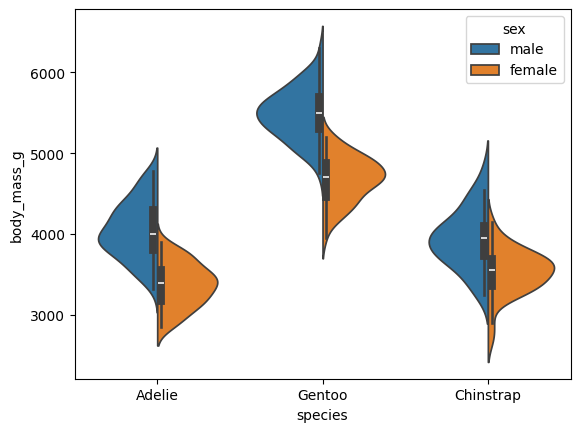

In [7]:
sns.violinplot(x='species',y='body_mass_g',hue='sex',data= data,split=True)

In [8]:
data[data['bill_length_mm'].isnull()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [9]:
data.dropna(subset=['bill_length_mm'],inplace=True)

In [10]:
data['sex'] = data['sex'].fillna('unknow')

In [11]:
data.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [12]:
# 문자로 이루어진 데이터는 숫자로 라벨링

data['species'] = data['species'].map({'Adelie':0,'Gentoo':1,'Chinstrap':2})
data['island'] = data['island'].map({'Biscoe':0,'Dream':1,'Torgersen':2})
data['sex'] = data['sex'].map({'male':0,'female':1,'unknow':2})
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,0
1,0,2,39.5,17.4,186.0,3800.0,1
2,0,2,40.3,18.0,195.0,3250.0,1
4,0,2,36.7,19.3,193.0,3450.0,1
5,0,2,39.3,20.6,190.0,3650.0,0
...,...,...,...,...,...,...,...
339,2,1,55.8,19.8,207.0,4000.0,0
340,2,1,43.5,18.1,202.0,3400.0,1
341,2,1,49.6,18.2,193.0,3775.0,0
342,2,1,50.8,19.0,210.0,4100.0,0


In [13]:
x = data.drop('species', axis=1)
y = data['species']

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=0
)

SVC 핵심은 vector경계인 선을 찾는 것.  
차원이 늘어날수록 계산량이 증가하는 부작용이 발생.  
이를 해결해주는 것이 커널 함수     

.

커널의 종류 : linear, poly,rbf,sigmoid,precomputed  
기본값은 rbf

.  
부리의 길이, 부리의 두께, 물갈퀴의 길이 , 체중 , 성별  

In [15]:
model = svm.SVC()

In [16]:
model.fit(X_train,y_train)

SVC()

In [17]:
model.score(X_train,y_train)

0.73992673992674

In [18]:
y_pred = model.predict(X_test).flatten()

In [19]:
for i in range(10):
    label = y_test.iloc[i]
    pred = y_pred[i]
    print(label, pred)

0 1
2 0
0 1
2 0
0 1
2 0
1 1
0 0
1 1
0 0


In [20]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[30  6  0]
 [ 1 19  0]
 [13  0  0]]
              precision    recall  f1-score   support

           0       0.68      0.83      0.75        36
           1       0.76      0.95      0.84        20
           2       0.00      0.00      0.00        13

    accuracy                           0.71        69
   macro avg       0.48      0.59      0.53        69
weighted avg       0.58      0.71      0.64        69



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# SVM 시각화

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/penguins.csv')
data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [22]:
svm_y = data['species']
svm_x = data.drop(columns='species')

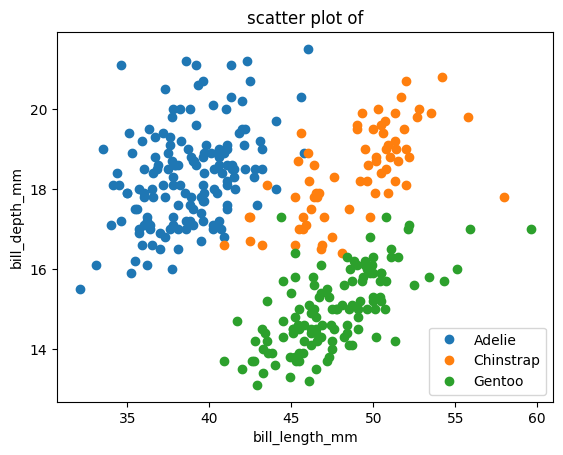

In [23]:
from itertools import groupby
# 펭귄 종 별로 데이터 그룹 후,
# 부리의 길이와 두께로 그룹해서 종별로 시각화
groups = data.groupby('species')
fig,ax = plt.subplots()
for name,group in groups:
  ax.plot(group.bill_length_mm,group.bill_depth_mm,
          marker='o',linestyle='',label=name)
ax.legend(fontsize=10,loc='lower right')
plt.title('scatter plot of')
plt.xlabel('bill_length_mm')
plt.ylabel('bill_depth_mm')
plt.show()

In [24]:
svm_test= data[(data['species']!='Chinstrap')]
svm_test = svm_test.drop(['island','flipper_length_mm','body_mass_g','sex'],axis=1)
svm_test.dropna(subset=['bill_length_mm'],inplace=True)

svm_test=svm_test.replace('Adelie',0)
svm_test=svm_test.replace('Gentoo',1)
svm_test

/tmp/ipython-input-1410204984.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  svm_test=svm_test.replace('Gentoo',1)


,species,bill_length_mm,bill_depth_mm
0,0,39.1,18.7
1,0,39.5,17.4
2,0,40.3,18.0
4,0,36.7,19.3
5,0,39.3,20.6
...,...,...,...
270,1,47.2,13.7
272,1,46.8,14.3
273,1,50.4,15.7
274,1,45.2,14.8


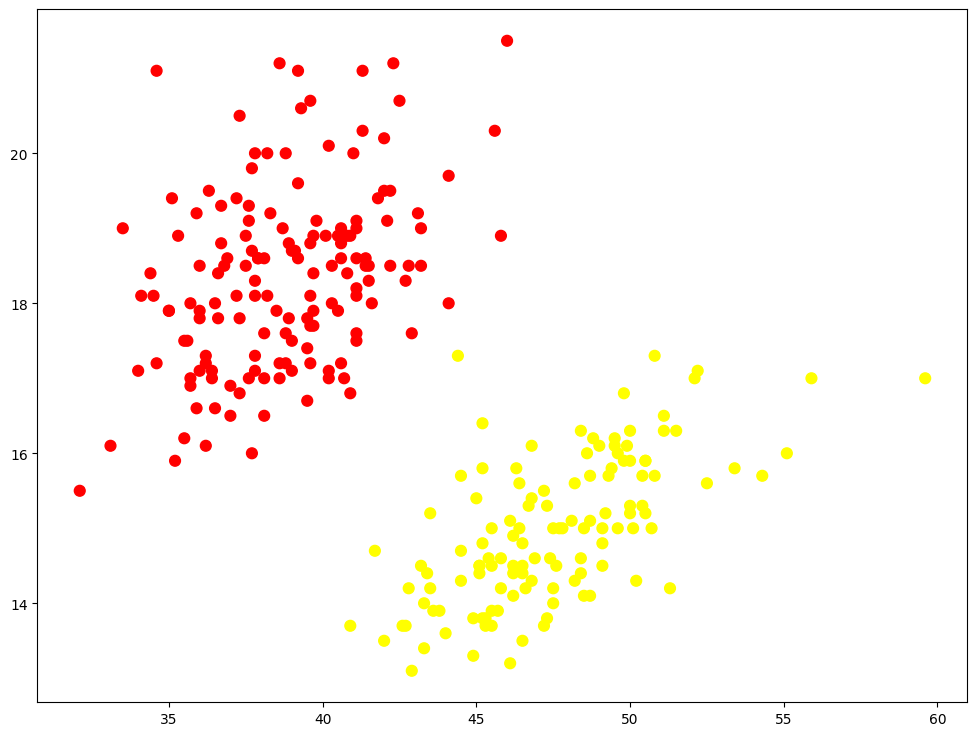

In [25]:
svm_x = svm_test.iloc[:, 1:3]
svm_y = svm_test['species']
plt.figure(figsize=(12,9))
plt.scatter(svm_x.iloc[:,0],svm_x.iloc[:,1],c=svm_y,s=60,cmap='autumn')
plt.show()

In [28]:
model = svm.SVC(kernel='linear',C=10)
model.fit(svm_x,svm_y)

SVC(C=10, kernel='linear')

In [29]:
model.support_vectors_

array([[44.1, 18. ],
       [44.4, 17.3]])

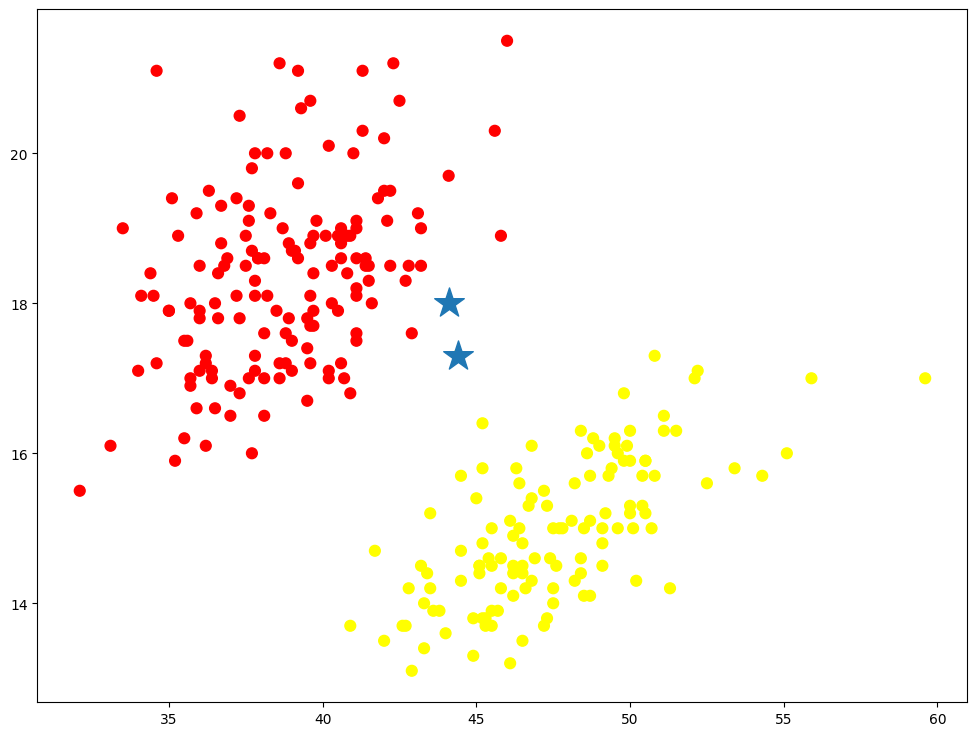

In [30]:
plt.figure(figsize=(12,9))
plt.scatter(svm_x.iloc[:,0],svm_x.iloc[:,1],c=svm_y,s=60,cmap='autumn')
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=500,marker='*')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


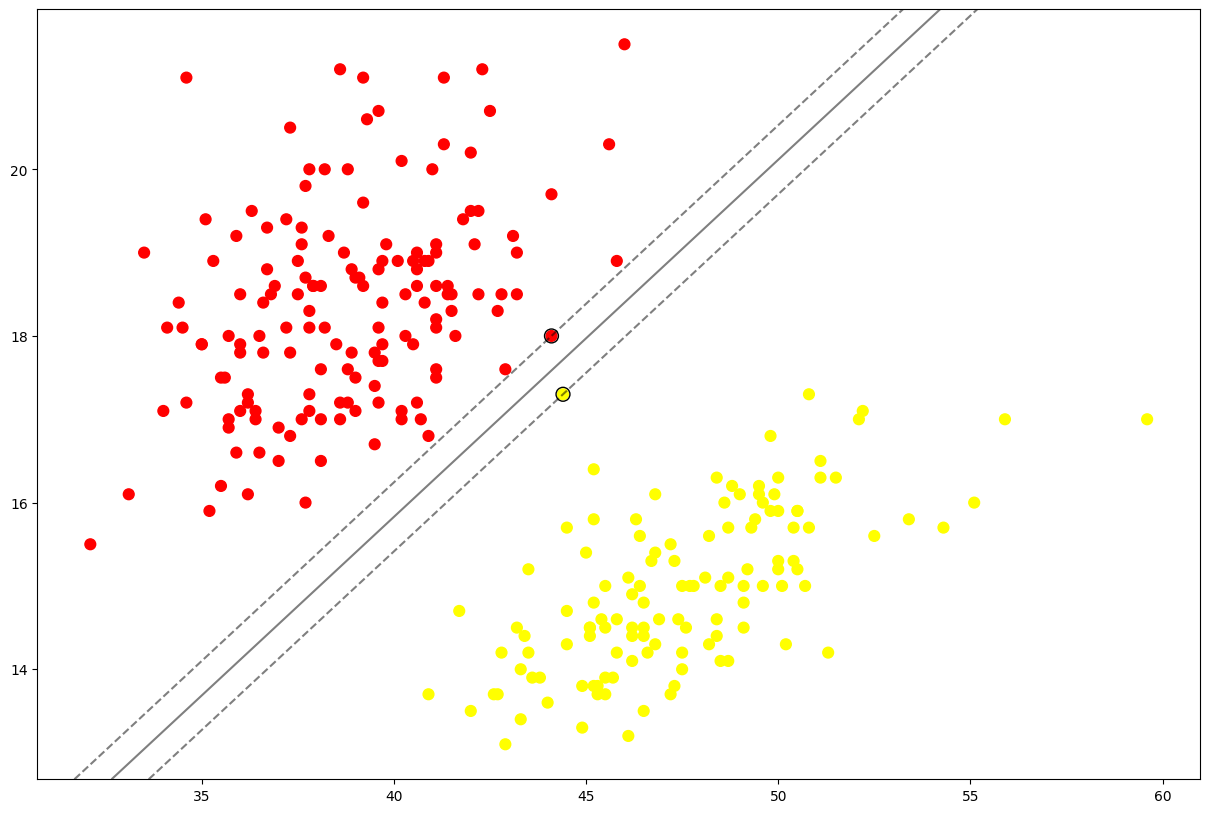

In [31]:
plt.figure(figsize=(15,10))
ax = plt.gca()
plt.scatter(svm_x.iloc[:, 0], svm_x.iloc[:, 1], c=svm_y, s=60, cmap='autumn')
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')
plt.show()

# 02. 당뇨병 판별

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

In [33]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/diabetes_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Gender              520 non-null    int64
 1   Polyuria            520 non-null    int64
 2   Polydipsia          520 non-null    int64
 3   sudden weight loss  520 non-null    int64
 4   weakness            520 non-null    int64
 5   Polyphagia          520 non-null    int64
 6   Genital thrush      520 non-null    int64
 7   visual blurring     520 non-null    int64
 8   Itching             520 non-null    int64
 9   Irritability        520 non-null    int64
 10  delayed healing     520 non-null    int64
 11  partial paresis     520 non-null    int64
 12  muscle stiffness    520 non-null    int64
 13  Alopecia            520 non-null    int64
 14  Obesity             520 non-null    int64
 15  class               520 non-null    int64
dtypes: int64(16)
memory usage: 65.1 KB


In [34]:
y = data['class']
x = data.drop(columns='class')

In [35]:
X_train,X_test,y_train,y_test=train_test_split(
    x,y,test_size=0.3,random_state=0
)

In [36]:
model = svm.SVC()
model.fit(X_train,y_train)

SVC()

In [37]:
model.score(X_train,y_train)

0.9807692307692307

In [38]:
y_pred = model.predict(X_test).flatten()

In [39]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9615384615384616
[[59  3]
 [ 3 91]]


# 03. SVM - 다중분류 IRIS

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

In [42]:
data = load_iris()

In [47]:
df = pd.DataFrame(data=data.data,columns=data.feature_names)
df['target']=data.target

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [51]:
X=df.drop(columns=['target'])
y=df["target"]

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
model=svm.SVC(random_state=42)

In [59]:
model.fit(X_train,y_train)

SVC(random_state=42)

In [60]:
model.score(X_train,y_train)

0.975

In [61]:
y_pred = model.predict(X_test).flatten()

In [62]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
